In [18]:
RANKS = "AKQJT98765432"

def generate_169_categories():
    categories = []

    for i, r1 in enumerate(RANKS):
        for j, r2 in enumerate(RANKS):
            if i == j:
                categories.append(r1 + r2)      # pair, like AA
            elif i < j:
                categories.append(r1 + r2 + "s") # suited
            else:
                categories.append(r2 + r1 + "o") # offsuit

    return categories

cats = generate_169_categories()
print(len(cats))
print(cats)

169
['AA', 'AKs', 'AQs', 'AJs', 'ATs', 'A9s', 'A8s', 'A7s', 'A6s', 'A5s', 'A4s', 'A3s', 'A2s', 'AKo', 'KK', 'KQs', 'KJs', 'KTs', 'K9s', 'K8s', 'K7s', 'K6s', 'K5s', 'K4s', 'K3s', 'K2s', 'AQo', 'KQo', 'QQ', 'QJs', 'QTs', 'Q9s', 'Q8s', 'Q7s', 'Q6s', 'Q5s', 'Q4s', 'Q3s', 'Q2s', 'AJo', 'KJo', 'QJo', 'JJ', 'JTs', 'J9s', 'J8s', 'J7s', 'J6s', 'J5s', 'J4s', 'J3s', 'J2s', 'ATo', 'KTo', 'QTo', 'JTo', 'TT', 'T9s', 'T8s', 'T7s', 'T6s', 'T5s', 'T4s', 'T3s', 'T2s', 'A9o', 'K9o', 'Q9o', 'J9o', 'T9o', '99', '98s', '97s', '96s', '95s', '94s', '93s', '92s', 'A8o', 'K8o', 'Q8o', 'J8o', 'T8o', '98o', '88', '87s', '86s', '85s', '84s', '83s', '82s', 'A7o', 'K7o', 'Q7o', 'J7o', 'T7o', '97o', '87o', '77', '76s', '75s', '74s', '73s', '72s', 'A6o', 'K6o', 'Q6o', 'J6o', 'T6o', '96o', '86o', '76o', '66', '65s', '64s', '63s', '62s', 'A5o', 'K5o', 'Q5o', 'J5o', 'T5o', '95o', '85o', '75o', '65o', '55', '54s', '53s', '52s', 'A4o', 'K4o', 'Q4o', 'J4o', 'T4o', '94o', '84o', '74o', '64o', '54o', '44', '43s', '42s', 'A3o'

In [19]:
RANK_ORDER = {r: i for i, r in enumerate("23456789TJQKA", start=2)}

def hand_to_category(card1, card2):
    r1, s1 = card1[0], card1[1]
    r2, s2 = card2[0], card2[1]

    # Pair
    if r1 == r2:
        return r1 + r2

    # Order ranks high to low
    if RANK_ORDER[r1] > RANK_ORDER[r2]:
        high, low = r1, r2
        suit_same = (s1 == s2)
    else:
        high, low = r2, r1
        suit_same = (s1 == s2)

    if suit_same:
        return high + low + "s"
    else:
        return high + low + "o"


print(hand_to_category("As", "Ks"))  # AKs
print(hand_to_category("Ah", "Kd"))  # AKo
print(hand_to_category("9c", "9d"))  # 99

AKs
AKo
99


In [20]:
import random

RANKS_FULL = "23456789TJQKA"
SUITS = "shdc"

def create_deck():
    return [r + s for r in RANKS_FULL for s in SUITS]

In [28]:
from itertools import combinations

def all_combos_for_category(category):
    deck = create_deck()
    combos = []

    for c1, c2 in combinations(deck, 2):
        if hand_to_category(c1, c2) == category:
            combos.append((c1, c2))

    return combos

print(len(all_combos_for_category("AKs")))  # 4
print(len(all_combos_for_category("AKo")))  # 12
print(len(all_combos_for_category("AA")))   # 6


4
12
6


In [34]:
def monte_carlo_preflop_category(category, trials=5000):
    hero_combos = all_combos_for_category(category)

    win = tie = lose = 0

    for _ in range(trials):
        # random choose one actual combo from this category
        hero_hole = list(random.choice(hero_combos))

        deck = create_deck()
        for c in hero_hole:
            deck.remove(c)

        random.shuffle(deck)

        rival_hole = deck[:2]
        board = deck[2:7]

        hero_7 = hero_hole + board
        rival_7 = rival_hole + board

        result = compare_hands(hero_7, rival_7)

        if result == 1:
            win += 1
        elif result == 0:
            tie += 1
        else:
            lose += 1

    return {
        "category": category,
        "win_prob": win / trials,
        "tie_prob": tie / trials,
        "lose_prob": lose / trials
    }

print(monte_carlo_preflop_category("AKs", trials=2000))
print(monte_carlo_preflop_category("72o", trials=2000))
print(monte_carlo_preflop_category("AA", trials=2000))

{'category': 'AKs', 'win_prob': 0.6435, 'tie_prob': 0.0165, 'lose_prob': 0.34}
{'category': '72o', 'win_prob': 0.316, 'tie_prob': 0.061, 'lose_prob': 0.623}
{'category': 'AA', 'win_prob': 0.85, 'tie_prob': 0.0065, 'lose_prob': 0.1435}


In [35]:
"Q1"
import pandas as pd

def analyze_all_169_preflop(trials=3000):
    categories = generate_169_categories()
    results = []

    for cat in categories:
        res = monte_carlo_preflop_category(cat, trials=trials)
        results.append(res)

    df = pd.DataFrame(results)
    df = df.sort_values("win_prob", ascending=False).reset_index(drop=True)
    return df

df_169 = analyze_all_169_preflop(trials=2000)
print(df_169.head())

  category  win_prob  tie_prob  lose_prob
0       AA    0.8390     0.009     0.1520
1       KK    0.8225     0.006     0.1715
2       QQ    0.7955     0.007     0.1975
3       JJ    0.7590     0.008     0.2330
4       TT    0.7430     0.005     0.2520


In [10]:
"Q2"
def compare_suited_offsuit(rank1, rank2, trials=5000):
    suited_cat = rank1 + rank2 + "s"
    offsuit_cat = rank1 + rank2 + "o"

    suited_res = monte_carlo_preflop_category(suited_cat, trials=trials)
    offsuit_res = monte_carlo_preflop_category(offsuit_cat, trials=trials)

    return {
        "suited": suited_cat,
        "suited_win": suited_res["win_prob"],
        "offsuit": offsuit_cat,
        "offsuit_win": offsuit_res["win_prob"],
        "difference": suited_res["win_prob"] - offsuit_res["win_prob"]
    }

print(compare_suited_offsuit("A", "K", trials=3000))
print(compare_suited_offsuit("Q", "J", trials=3000))
print(compare_suited_offsuit("9", "8", trials=3000))

{'suited': 'AKs', 'suited_win': 0.6676666666666666, 'offsuit': 'AKo', 'offsuit_win': 0.6416666666666667, 'difference': 0.025999999999999912}
{'suited': 'QJs', 'suited_win': 0.5856666666666667, 'offsuit': 'QJo', 'offsuit_win': 0.574, 'difference': 0.011666666666666714}
{'suited': '98s', 'suited_win': 0.5013333333333333, 'offsuit': '98o', 'offsuit_win': 0.4656666666666667, 'difference': 0.035666666666666624}


In [12]:
"Q3"
def analyze_pairs_preflop(trials=4000):
    pair_cats = [r + r for r in "AKQJT98765432"]
    results = []

    for cat in pair_cats:
        results.append(monte_carlo_preflop_category(cat, trials=trials))

    df = pd.DataFrame(results).sort_values("win_prob", ascending=False)
    return df

df_pairs = analyze_pairs_preflop(trials=3000)
print(df_pairs)

   category  win_prob  tie_prob  lose_prob
0        AA  0.846333  0.005667   0.148000
1        KK  0.811667  0.005333   0.183000
2        QQ  0.807333  0.005333   0.187333
3        JJ  0.782333  0.004000   0.213667
4        TT  0.734000  0.006667   0.259333
5        99  0.712333  0.009000   0.278667
6        88  0.684000  0.011000   0.305000
7        77  0.647000  0.008333   0.344667
8        66  0.626000  0.012000   0.362000
9        55  0.608667  0.016333   0.375000
10       44  0.551333  0.016333   0.432333
11       33  0.520000  0.020000   0.460000
12       22  0.487667  0.017000   0.495333


Running analysis for all 169 starting-hand categories...
Plotting figures...


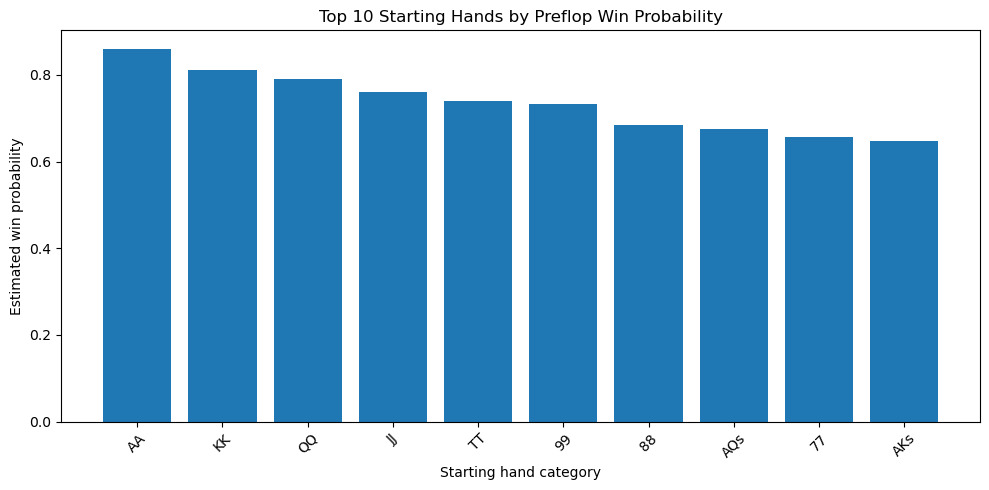

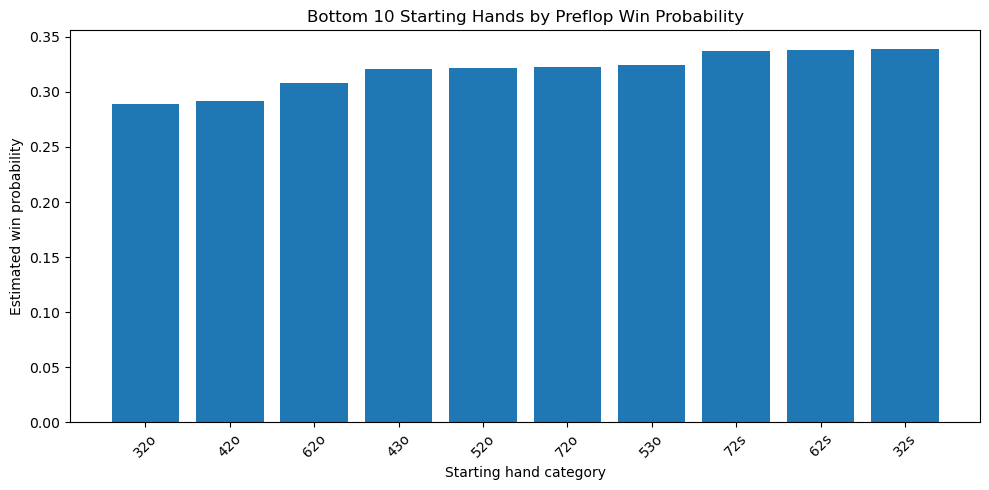

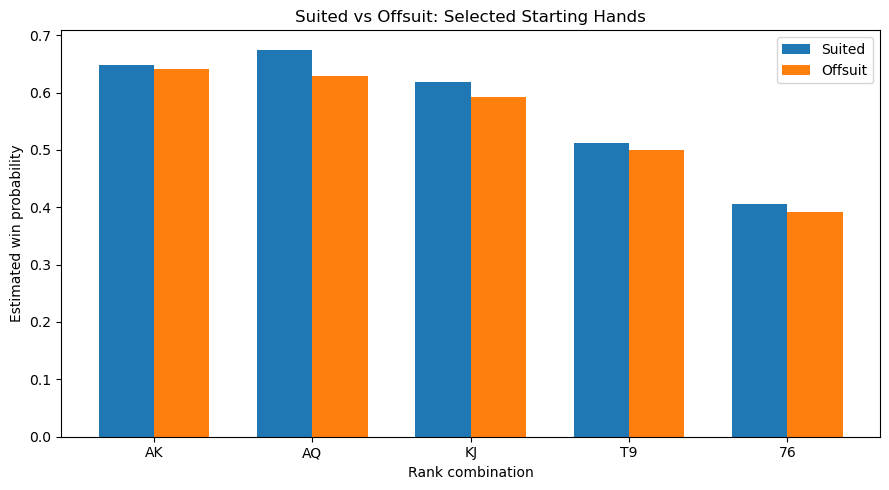

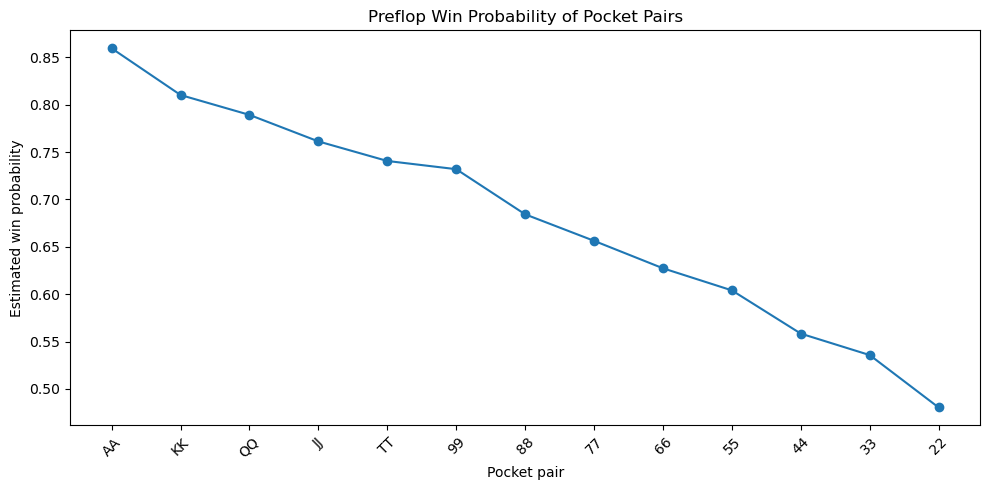

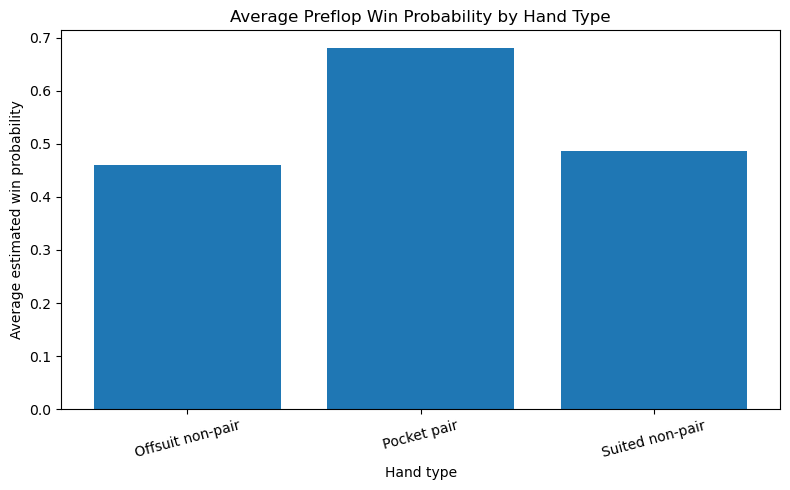


Top 10 starting hands:
  category  win_prob
0       AA  0.859667
1       KK  0.810333
2       QQ  0.789333
3       JJ  0.761333
4       TT  0.740667
5       99  0.732000
6       88  0.684333
7      AQs  0.674667
8       77  0.656333
9      AKs  0.647333

Group averages:
              group  win_prob
0  Offsuit non-pair  0.460761
1       Pocket pair  0.679974
2   Suited non-pair  0.487214

All results and figures saved in folder: /home/chalo/Desktop/texas_holdem_outputs


In [36]:
"Q1-3"
import random
from itertools import combinations
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. BASIC CARD / CATEGORY SETUP
# =========================================================

RANKS_ANALYSIS = "AKQJT98765432"   # for 169-category ordering
RANKS_FULL = "23456789TJQKA"
SUITS = "shdc"   # spades, hearts, diamonds, clubs

RANK_ORDER = {r: i for i, r in enumerate(RANKS_FULL, start=2)}
RANK_VALUE = {r: i for i, r in enumerate(RANKS_FULL, start=2)}


def create_deck():
    """Create a standard 52-card deck."""
    return [r + s for r in RANKS_FULL for s in SUITS]


def hand_to_category(card1, card2):
    """
    Convert two actual cards into one of the 169 hand categories.
    Examples:
        As Ks -> AKs
        Ah Kd -> AKo
        9c 9d -> 99
    """
    r1, s1 = card1[0], card1[1]
    r2, s2 = card2[0], card2[1]

    # pocket pair
    if r1 == r2:
        return r1 + r2

    # high rank first
    if RANK_ORDER[r1] > RANK_ORDER[r2]:
        high, low = r1, r2
    else:
        high, low = r2, r1

    suited = (s1 == s2)

    if suited:
        return high + low + "s"
    else:
        return high + low + "o"


def generate_169_categories():
    """
    Generate the 169 starting-hand categories in 13x13 style order.
    """
    categories = []
    for i, r1 in enumerate(RANKS_ANALYSIS):
        for j, r2 in enumerate(RANKS_ANALYSIS):
            if i == j:
                categories.append(r1 + r2)         # pair
            elif i < j:
                categories.append(r1 + r2 + "s")   # suited
            else:
                categories.append(r2 + r1 + "o")   # offsuit
    return categories


# =========================================================
# 2. PRECOMPUTE ALL REAL 2-CARD COMBOS FOR EACH CATEGORY
# =========================================================

ALL_DECK = create_deck()
ALL_2CARD_COMBOS = list(combinations(ALL_DECK, 2))

CATEGORY_TO_COMBOS = {}
for c1, c2 in ALL_2CARD_COMBOS:
    cat = hand_to_category(c1, c2)
    CATEGORY_TO_COMBOS.setdefault(cat, []).append((c1, c2))


# =========================================================
# 3. POKER HAND EVALUATOR
# =========================================================

def card_rank(card):
    return card[0]


def card_suit(card):
    return card[1]


def evaluate_5card_hand(cards):
    """
    Evaluate a 5-card poker hand.
    Returns a tuple; larger tuple means stronger hand.

    Hand categories:
    8 = straight flush
    7 = four of a kind
    6 = full house
    5 = flush
    4 = straight
    3 = three of a kind
    2 = two pair
    1 = one pair
    0 = high card
    """
    ranks = sorted([RANK_VALUE[card_rank(c)] for c in cards], reverse=True)
    suits = [card_suit(c) for c in cards]

    rank_counter = Counter(ranks)
    counts = sorted(rank_counter.values(), reverse=True)
    unique_ranks = sorted(set(ranks), reverse=True)

    is_flush = len(set(suits)) == 1

    # straight check
    straight_high = None
    if len(unique_ranks) == 5:
        if unique_ranks[0] - unique_ranks[4] == 4:
            straight_high = unique_ranks[0]
        elif unique_ranks == [14, 5, 4, 3, 2]:  # A-2-3-4-5
            straight_high = 5

    is_straight = straight_high is not None

    if is_straight and is_flush:
        return (8, straight_high)

    if counts == [4, 1]:
        quad = max(r for r, c in rank_counter.items() if c == 4)
        kicker = max(r for r, c in rank_counter.items() if c == 1)
        return (7, quad, kicker)

    if counts == [3, 2]:
        triple = max(r for r, c in rank_counter.items() if c == 3)
        pair = max(r for r, c in rank_counter.items() if c == 2)
        return (6, triple, pair)

    if is_flush:
        return (5, *ranks)

    if is_straight:
        return (4, straight_high)

    if counts == [3, 1, 1]:
        triple = max(r for r, c in rank_counter.items() if c == 3)
        kickers = sorted([r for r, c in rank_counter.items() if c == 1], reverse=True)
        return (3, triple, *kickers)

    if counts == [2, 2, 1]:
        pairs = sorted([r for r, c in rank_counter.items() if c == 2], reverse=True)
        kicker = max(r for r, c in rank_counter.items() if c == 1)
        return (2, *pairs, kicker)

    if counts == [2, 1, 1, 1]:
        pair = max(r for r, c in rank_counter.items() if c == 2)
        kickers = sorted([r for r, c in rank_counter.items() if c == 1], reverse=True)
        return (1, pair, *kickers)

    return (0, *ranks)


def best_7card_hand(cards7):
    """Choose the best 5-card hand out of 7 cards."""
    return max(evaluate_5card_hand(list(combo)) for combo in combinations(cards7, 5))


def compare_hands(hero_cards7, rival_cards7):
    """
    Return:
        1  -> hero wins
        0  -> tie
       -1  -> hero loses
    """
    hero_rank = best_7card_hand(hero_cards7)
    rival_rank = best_7card_hand(rival_cards7)

    if hero_rank > rival_rank:
        return 1
    elif hero_rank < rival_rank:
        return -1
    return 0


# =========================================================
# 4. MONTE CARLO SIMULATION FOR ONE CATEGORY
# =========================================================

def monte_carlo_preflop_category(category, trials=3000, rng=None):
    """
    Estimate preflop win/tie/lose probabilities for a given category
    in heads-up Texas Hold'em.
    """
    if rng is None:
        rng = random.Random()

    hero_combos = CATEGORY_TO_COMBOS[category]

    win = 0
    tie = 0
    lose = 0

    for _ in range(trials):
        hero_hole = list(rng.choice(hero_combos))

        deck = ALL_DECK.copy()
        for c in hero_hole:
            deck.remove(c)

        rng.shuffle(deck)

        rival_hole = deck[:2]
        board = deck[2:7]

        hero_7 = hero_hole + board
        rival_7 = rival_hole + board

        result = compare_hands(hero_7, rival_7)

        if result == 1:
            win += 1
        elif result == 0:
            tie += 1
        else:
            lose += 1

    return {
        "category": category,
        "win_prob": win / trials,
        "tie_prob": tie / trials,
        "lose_prob": lose / trials
    }


# =========================================================
# 5. ANALYSIS FUNCTIONS
# =========================================================

def hand_group(category):
    """
    Group categories into:
    - Pocket pair
    - Suited non-pair
    - Offsuit non-pair
    """
    if len(category) == 2:
        return "Pocket pair"
    elif category.endswith("s"):
        return "Suited non-pair"
    else:
        return "Offsuit non-pair"


def analyze_all_169_preflop(trials=3000, seed=42):
    """
    Run Monte Carlo for all 169 categories.
    """
    rng = random.Random(seed)
    categories = generate_169_categories()
    results = []

    for cat in categories:
        results.append(monte_carlo_preflop_category(cat, trials=trials, rng=rng))

    df = pd.DataFrame(results)
    df["group"] = df["category"].apply(hand_group)
    df = df.sort_values("win_prob", ascending=False).reset_index(drop=True)
    return df


def build_suited_offsuit_comparison(df, rank_pairs=None):
    """
    Compare suited vs offsuit for selected rank combinations.
    Example rank_pairs:
        [("A","K"), ("A","Q"), ("K","J"), ("T","9"), ("7","6")]
    """
    if rank_pairs is None:
        rank_pairs = [("A", "K"), ("A", "Q"), ("K", "J"), ("T", "9"), ("7", "6")]

    rows = []
    for r1, r2 in rank_pairs:
        suited_cat = r1 + r2 + "s"
        offsuit_cat = r1 + r2 + "o"

        suited_win = float(df.loc[df["category"] == suited_cat, "win_prob"].iloc[0])
        offsuit_win = float(df.loc[df["category"] == offsuit_cat, "win_prob"].iloc[0])

        rows.append({
            "label": f"{r1}{r2}",
            "suited_category": suited_cat,
            "suited_win_prob": suited_win,
            "offsuit_category": offsuit_cat,
            "offsuit_win_prob": offsuit_win,
            "difference": suited_win - offsuit_win
        })

    return pd.DataFrame(rows)


def build_pocket_pair_table(df):
    """
    Extract pocket pairs in order AA -> 22.
    """
    pair_order = [r + r for r in "AKQJT98765432"]
    df_pairs = df[df["category"].isin(pair_order)].copy()
    df_pairs["category"] = pd.Categorical(df_pairs["category"], categories=pair_order, ordered=True)
    df_pairs = df_pairs.sort_values("category")
    return df_pairs


def build_group_average_table(df):
    """
    Average win probability by group.
    """
    return df.groupby("group", as_index=False)["win_prob"].mean()


# =========================================================
# 6. PLOTTING FUNCTIONS
# =========================================================

def plot_top10(df, output_dir):
    top10 = df.head(10)

    plt.figure(figsize=(10, 5))
    plt.bar(top10["category"], top10["win_prob"])
    plt.title("Top 10 Starting Hands by Preflop Win Probability")
    plt.xlabel("Starting hand category")
    plt.ylabel("Estimated win probability")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_dir / "figure1_top10_starting_hands.png", dpi=200)
    plt.show()
    plt.close()


def plot_bottom10(df, output_dir):
    bottom10 = df.tail(10).sort_values("win_prob", ascending=True)

    plt.figure(figsize=(10, 5))
    plt.bar(bottom10["category"], bottom10["win_prob"])
    plt.title("Bottom 10 Starting Hands by Preflop Win Probability")
    plt.xlabel("Starting hand category")
    plt.ylabel("Estimated win probability")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_dir / "figure2_bottom10_starting_hands.png", dpi=200)
    plt.show()
    plt.close()


def plot_suited_vs_offsuit(df_suited, output_dir):
    x = range(len(df_suited))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar([i - width/2 for i in x], df_suited["suited_win_prob"], width=width, label="Suited")
    plt.bar([i + width/2 for i in x], df_suited["offsuit_win_prob"], width=width, label="Offsuit")
    plt.title("Suited vs Offsuit: Selected Starting Hands")
    plt.xlabel("Rank combination")
    plt.ylabel("Estimated win probability")
    plt.xticks(list(x), df_suited["label"])
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "figure3_suited_vs_offsuit.png", dpi=200)
    plt.show()
    plt.close()


def plot_pocket_pairs(df_pairs, output_dir):
    plt.figure(figsize=(10, 5))
    plt.plot(df_pairs["category"].astype(str), df_pairs["win_prob"], marker="o")
    plt.title("Preflop Win Probability of Pocket Pairs")
    plt.xlabel("Pocket pair")
    plt.ylabel("Estimated win probability")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(output_dir / "figure4_pocket_pairs.png", dpi=200)
    plt.show()
    plt.close()


def plot_group_averages(df_group, output_dir):
    plt.figure(figsize=(8, 5))
    plt.bar(df_group["group"], df_group["win_prob"])
    plt.title("Average Preflop Win Probability by Hand Type")
    plt.xlabel("Hand type")
    plt.ylabel("Average estimated win probability")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(output_dir / "figure5_group_averages.png", dpi=200)
    plt.show()
    plt.close()


# =========================================================
# 7. MAIN PROGRAM
# =========================================================

def main():
    # You can increase trials later for more stable results
    trials = 3000

    # Output folder
    output_dir = Path("texas_holdem_outputs")
    output_dir.mkdir(exist_ok=True)

    # -------------------------
    # Run main analysis
    # -------------------------
    print("Running analysis for all 169 starting-hand categories...")
    df_all = analyze_all_169_preflop(trials=trials, seed=42)

    # Save all results
    df_all.to_csv(output_dir / "all_169_preflop_results.csv", index=False)

    # -------------------------
    # Build tables for Q2 and Q3
    # -------------------------
    df_suited = build_suited_offsuit_comparison(df_all)
    df_pairs = build_pocket_pair_table(df_all)
    df_group = build_group_average_table(df_all)

    df_suited.to_csv(output_dir / "selected_suited_vs_offsuit.csv", index=False)
    df_pairs.to_csv(output_dir / "pocket_pairs.csv", index=False)
    df_group.to_csv(output_dir / "group_averages.csv", index=False)

    # -------------------------
    # Plot figures
    # -------------------------
    print("Plotting figures...")
    plot_top10(df_all, output_dir)
    plot_bottom10(df_all, output_dir)
    plot_suited_vs_offsuit(df_suited, output_dir)
    plot_pocket_pairs(df_pairs, output_dir)
    plot_group_averages(df_group, output_dir)

    # -------------------------
    # Print summary
    # -------------------------
    print("\nTop 10 starting hands:")
    print(df_all.head(10)[["category", "win_prob"]])

    print("\nGroup averages:")
    print(df_group)

    print(f"\nAll results and figures saved in folder: {output_dir.resolve()}")


if __name__ == "__main__":
    main()

Running question 4 analysis...
Plotting figures...


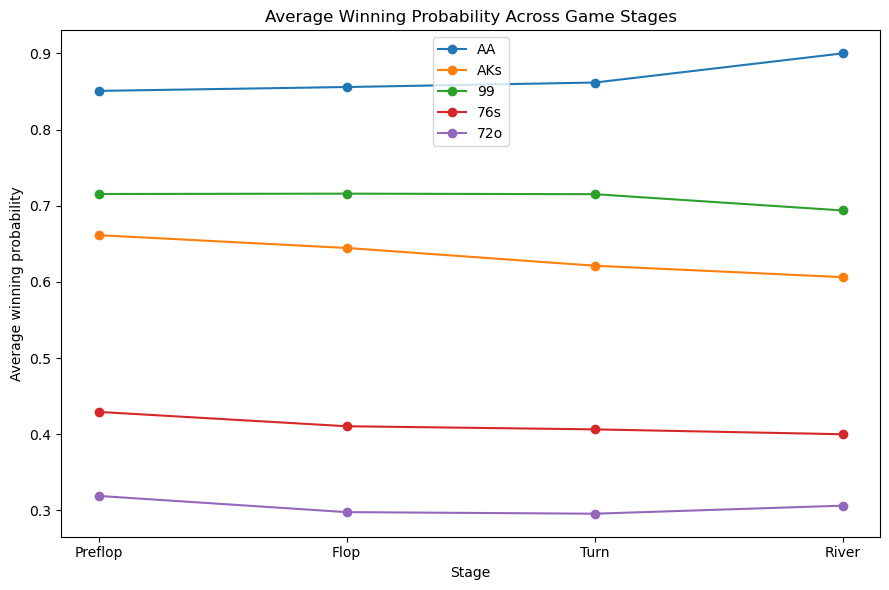

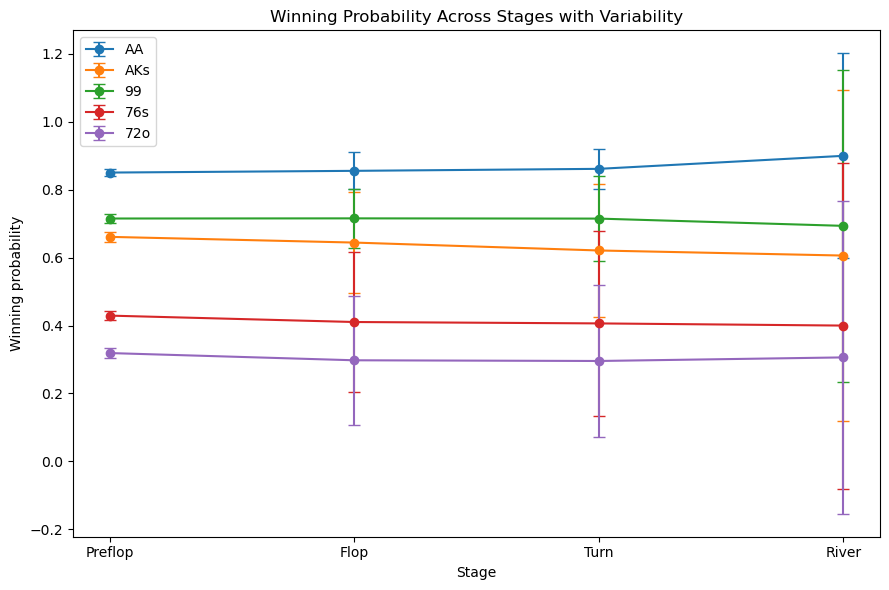

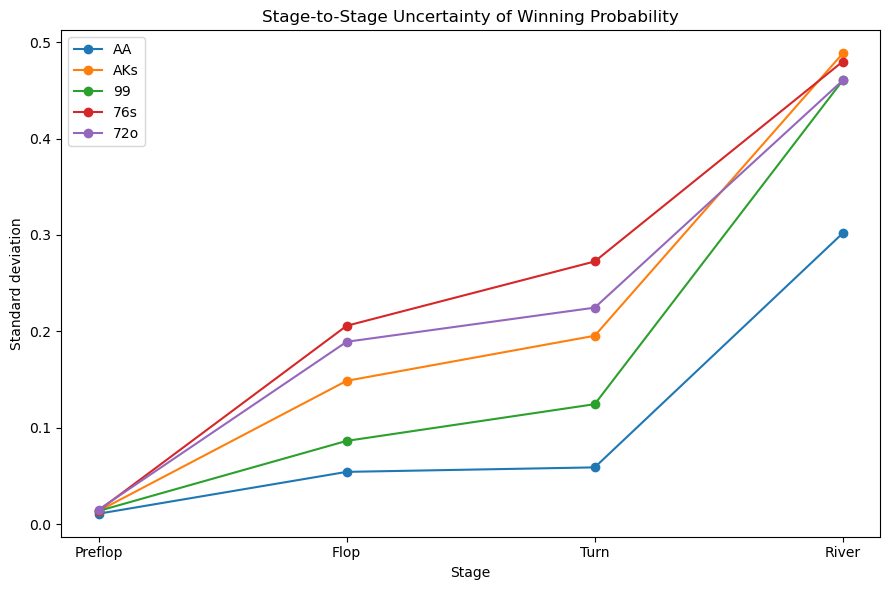


Stage summary:
   category    stage  mean_win_prob  std_win_prob
0        AA  Preflop       0.850729      0.010853
1        AA     Flop       0.855802      0.054257
2        AA     Turn       0.861667      0.058912
3        AA    River       0.900000      0.301893
4       AKs  Preflop       0.661323      0.013713
5       AKs     Flop       0.644531      0.148723
6       AKs     Turn       0.621229      0.195470
7       AKs    River       0.606250      0.488434
8        99  Preflop       0.715375      0.013726
9        99     Flop       0.715823      0.086404
10       99     Turn       0.715125      0.124484
11       99    River       0.693750      0.460419
12      76s  Preflop       0.429333      0.014165
13      76s     Flop       0.410500      0.205816
14      76s     Turn       0.406396      0.272540
15      76s    River       0.400000      0.479979
16      72o  Preflop       0.319031      0.015072
17      72o     Flop       0.297760      0.189219
18      72o     Turn       0.29568

In [37]:
import random
from itertools import combinations
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. BASIC CARD / CATEGORY SETUP
# =========================================================

RANKS_FULL = "23456789TJQKA"
SUITS = "shdc"
RANK_ORDER = {r: i for i, r in enumerate(RANKS_FULL, start=2)}
RANK_VALUE = {r: i for i, r in enumerate(RANKS_FULL, start=2)}


def create_deck():
    return [r + s for r in RANKS_FULL for s in SUITS]


def hand_to_category(card1, card2):
    r1, s1 = card1[0], card1[1]
    r2, s2 = card2[0], card2[1]

    if r1 == r2:
        return r1 + r2

    if RANK_ORDER[r1] > RANK_ORDER[r2]:
        high, low = r1, r2
    else:
        high, low = r2, r1

    suited = (s1 == s2)
    return high + low + ("s" if suited else "o")


ALL_DECK = create_deck()

CATEGORY_TO_COMBOS = {}
for c1, c2 in combinations(ALL_DECK, 2):
    cat = hand_to_category(c1, c2)
    CATEGORY_TO_COMBOS.setdefault(cat, []).append((c1, c2))


# =========================================================
# 2. POKER HAND EVALUATOR
# =========================================================

def card_rank(card):
    return card[0]


def card_suit(card):
    return card[1]


def evaluate_5card_hand(cards):
    ranks = sorted([RANK_VALUE[card_rank(c)] for c in cards], reverse=True)
    suits = [card_suit(c) for c in cards]

    rank_counter = Counter(ranks)
    counts = sorted(rank_counter.values(), reverse=True)
    unique_ranks = sorted(set(ranks), reverse=True)

    is_flush = len(set(suits)) == 1

    straight_high = None
    if len(unique_ranks) == 5:
        if unique_ranks[0] - unique_ranks[4] == 4:
            straight_high = unique_ranks[0]
        elif unique_ranks == [14, 5, 4, 3, 2]:
            straight_high = 5

    is_straight = straight_high is not None

    if is_straight and is_flush:
        return (8, straight_high)
    if counts == [4, 1]:
        quad = max(r for r, c in rank_counter.items() if c == 4)
        kicker = max(r for r, c in rank_counter.items() if c == 1)
        return (7, quad, kicker)
    if counts == [3, 2]:
        triple = max(r for r, c in rank_counter.items() if c == 3)
        pair = max(r for r, c in rank_counter.items() if c == 2)
        return (6, triple, pair)
    if is_flush:
        return (5, *ranks)
    if is_straight:
        return (4, straight_high)
    if counts == [3, 1, 1]:
        triple = max(r for r, c in rank_counter.items() if c == 3)
        kickers = sorted([r for r, c in rank_counter.items() if c == 1], reverse=True)
        return (3, triple, *kickers)
    if counts == [2, 2, 1]:
        pairs = sorted([r for r, c in rank_counter.items() if c == 2], reverse=True)
        kicker = max(r for r, c in rank_counter.items() if c == 1)
        return (2, *pairs, kicker)
    if counts == [2, 1, 1, 1]:
        pair = max(r for r, c in rank_counter.items() if c == 2)
        kickers = sorted([r for r, c in rank_counter.items() if c == 1], reverse=True)
        return (1, pair, *kickers)
    return (0, *ranks)


def best_7card_hand(cards7):
    return max(evaluate_5card_hand(list(combo)) for combo in combinations(cards7, 5))


def compare_hands(hero_cards7, rival_cards7):
    hero_rank = best_7card_hand(hero_cards7)
    rival_rank = best_7card_hand(rival_cards7)

    if hero_rank > rival_rank:
        return 1
    elif hero_rank < rival_rank:
        return -1
    return 0


# =========================================================
# 3. STAGE PROBABILITY ESTIMATOR
# =========================================================

def monte_carlo_stage_probability(hero_hole, visible_board, trials=2000, rng=None):
    """
    Estimate hero win/tie/lose probability given:
    - hero hole cards fixed
    - some board cards visible
    - rival hole cards unknown
    - remaining board cards unknown
    """
    if rng is None:
        rng = random.Random()

    known = hero_hole + visible_board
    deck = ALL_DECK.copy()
    for c in known:
        deck.remove(c)

    need_board = 5 - len(visible_board)

    win = 0
    tie = 0
    lose = 0

    for _ in range(trials):
        temp_deck = deck[:]
        rng.shuffle(temp_deck)

        rival_hole = temp_deck[:2]
        extra_board = temp_deck[2:2 + need_board]
        full_board = visible_board + extra_board

        hero_7 = hero_hole + full_board
        rival_7 = rival_hole + full_board

        result = compare_hands(hero_7, rival_7)

        if result == 1:
            win += 1
        elif result == 0:
            tie += 1
        else:
            lose += 1

    return {
        "win_prob": win / trials,
        "tie_prob": tie / trials,
        "lose_prob": lose / trials
    }


# =========================================================
# 4. QUESTION 4 ANALYSIS
# =========================================================

def analyze_stage_change_for_category(category, outer_trials=100, inner_trials=1500, seed=42):
    """
    For a chosen starting-hand category:
    - repeatedly sample one actual hero hand from that category
    - repeatedly generate one realized rival hand + full board
    - estimate win probability at preflop, flop, turn
    - record river final result
    - average across many realized games

    Returns a DataFrame with one row per realized game.
    """
    rng = random.Random(seed)
    hero_combos = CATEGORY_TO_COMBOS[category]

    records = []

    for _ in range(outer_trials):
        hero_hole = list(rng.choice(hero_combos))

        # generate one realized rival hand and full board
        deck = ALL_DECK.copy()
        for c in hero_hole:
            deck.remove(c)
        rng.shuffle(deck)

        rival_hole = deck[:2]
        board = deck[2:7]

        preflop_board = []
        flop_board = board[:3]
        turn_board = board[:4]
        river_board = board[:5]

        # estimate probability at each incomplete stage
        pre_res = monte_carlo_stage_probability(hero_hole, preflop_board, trials=inner_trials, rng=rng)
        flop_res = monte_carlo_stage_probability(hero_hole, flop_board, trials=inner_trials, rng=rng)
        turn_res = monte_carlo_stage_probability(hero_hole, turn_board, trials=inner_trials, rng=rng)

        # river: final realized outcome against the realized rival hand
        hero_7 = hero_hole + river_board
        rival_7 = rival_hole + river_board
        final_result = compare_hands(hero_7, rival_7)

        # convert final river outcome into "win value"
        if final_result == 1:
            river_value = 1.0
        elif final_result == 0:
            river_value = 0.5
        else:
            river_value = 0.0

        records.append({
            "category": category,
            "hero_hole_1": hero_hole[0],
            "hero_hole_2": hero_hole[1],
            "rival_hole_1": rival_hole[0],
            "rival_hole_2": rival_hole[1],
            "board_flop_1": flop_board[0],
            "board_flop_2": flop_board[1],
            "board_flop_3": flop_board[2],
            "board_turn": turn_board[3],
            "board_river": river_board[4],
            "preflop_win_prob": pre_res["win_prob"],
            "flop_win_prob": flop_res["win_prob"],
            "turn_win_prob": turn_res["win_prob"],
            "river_result_value": river_value
        })

    return pd.DataFrame(records)


def summarize_stage_results(df_stage):
    """
    Convert wide stage table into summary statistics:
    mean and std for each stage.
    """
    rows = []
    stage_columns = {
        "Preflop": "preflop_win_prob",
        "Flop": "flop_win_prob",
        "Turn": "turn_win_prob",
        "River": "river_result_value"
    }

    category = df_stage["category"].iloc[0]

    for stage_name, col in stage_columns.items():
        rows.append({
            "category": category,
            "stage": stage_name,
            "mean_win_prob": df_stage[col].mean(),
            "std_win_prob": df_stage[col].std()
        })

    return pd.DataFrame(rows)


def analyze_multiple_categories_stage_change(categories, outer_trials=100, inner_trials=1500, seed=42):
    """
    Run question 4 analysis for multiple hand categories.
    Returns:
    - all realized-game records
    - summary table by category and stage
    """
    all_records = []
    all_summaries = []

    for i, cat in enumerate(categories):
        df_stage = analyze_stage_change_for_category(
            cat,
            outer_trials=outer_trials,
            inner_trials=inner_trials,
            seed=seed + i
        )
        df_summary = summarize_stage_results(df_stage)

        all_records.append(df_stage)
        all_summaries.append(df_summary)

    df_all_records = pd.concat(all_records, ignore_index=True)
    df_all_summary = pd.concat(all_summaries, ignore_index=True)

    return df_all_records, df_all_summary


# =========================================================
# 5. PLOTTING FUNCTIONS
# =========================================================

def plot_stage_mean_lines(df_summary, output_dir):
    """
    Plot average win probability across stages for each category.
    """
    stage_order = ["Preflop", "Flop", "Turn", "River"]

    plt.figure(figsize=(9, 6))

    for category in df_summary["category"].unique():
        sub = df_summary[df_summary["category"] == category].copy()
        sub["stage"] = pd.Categorical(sub["stage"], categories=stage_order, ordered=True)
        sub = sub.sort_values("stage")

        plt.plot(sub["stage"], sub["mean_win_prob"], marker="o", label=category)

    plt.title("Average Winning Probability Across Game Stages")
    plt.xlabel("Stage")
    plt.ylabel("Average winning probability")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "figure_q4_stage_mean_lines.png", dpi=200)
    plt.show()
    plt.close()


def plot_stage_errorbars(df_summary, output_dir):
    """
    Plot average win probability with stage standard deviation as error bars.
    """
    stage_order = ["Preflop", "Flop", "Turn", "River"]

    plt.figure(figsize=(9, 6))

    for category in df_summary["category"].unique():
        sub = df_summary[df_summary["category"] == category].copy()
        sub["stage"] = pd.Categorical(sub["stage"], categories=stage_order, ordered=True)
        sub = sub.sort_values("stage")

        plt.errorbar(
            sub["stage"],
            sub["mean_win_prob"],
            yerr=sub["std_win_prob"],
            marker="o",
            capsize=4,
            label=category
        )

    plt.title("Winning Probability Across Stages with Variability")
    plt.xlabel("Stage")
    plt.ylabel("Winning probability")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "figure_q4_stage_errorbars.png", dpi=200)
    plt.show()
    plt.close()


def plot_stage_std_lines(df_summary, output_dir):
    """
    Plot stage uncertainty (standard deviation) across stages.
    """
    stage_order = ["Preflop", "Flop", "Turn", "River"]

    plt.figure(figsize=(9, 6))

    for category in df_summary["category"].unique():
        sub = df_summary[df_summary["category"] == category].copy()
        sub["stage"] = pd.Categorical(sub["stage"], categories=stage_order, ordered=True)
        sub = sub.sort_values("stage")

        plt.plot(sub["stage"], sub["std_win_prob"], marker="o", label=category)

    plt.title("Stage-to-Stage Uncertainty of Winning Probability")
    plt.xlabel("Stage")
    plt.ylabel("Standard deviation")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "figure_q4_stage_std_lines.png", dpi=200)
    plt.show()
    plt.close()


# =========================================================
# 6. MAIN PROGRAM
# =========================================================

def main():
    output_dir = Path("texas_holdem_q4_outputs")
    output_dir.mkdir(exist_ok=True)

    # Recommended categories for presentation
    categories = ["AA", "AKs", "99", "76s", "72o"]

    # outer_trials:
    #   number of realized games per category
    #
    # inner_trials:
    #   Monte Carlo trials used to estimate probability at each stage
    #
    # You can increase these later for final presentation.
    outer_trials = 80
    inner_trials = 1200

    print("Running question 4 analysis...")
    df_records, df_summary = analyze_multiple_categories_stage_change(
        categories=categories,
        outer_trials=outer_trials,
        inner_trials=inner_trials,
        seed=42
    )

    # Save tables
    df_records.to_csv(output_dir / "q4_stage_records.csv", index=False)
    df_summary.to_csv(output_dir / "q4_stage_summary.csv", index=False)

    print("Plotting figures...")
    plot_stage_mean_lines(df_summary, output_dir)
    plot_stage_errorbars(df_summary, output_dir)
    plot_stage_std_lines(df_summary, output_dir)

    print("\nStage summary:")
    print(df_summary)

    print(f"\nAll outputs saved to: {output_dir.resolve()}")


if __name__ == "__main__":
    main()